# Localización subcelular con embeddings de ESM-2

Alternativa a las representaciones "hechas a mano" (composición + fisicoquímicos, señales): usamos un **modelo de lenguaje de proteínas (ESM-2)** para convertir cada secuencia en un vector (embedding) y entrenamos un clasificador lineal encima.

Comparamos **ESM-2** contra **Random Forest** y una **red neuronal** sobre las features tabulares, con distintos tamaños de set de entrenamiento (**250, 750, 1500 y 3000 proteínas**), igual que en `overfitting.ipynb`.

**Corre en CPU** (no hace falta GPU). Usamos el modelo chico `facebook/esm2_t6_8M_UR50D` (8M parámetros). En Colab: `Entorno de ejecución → Cambiar tipo de entorno → CPU`.

Datos: subir `features_grande_composicion_senales.csv` (se genera una vez con `python data/05_dataset_grande.py`).

In [ ]:
# Colab ya trae torch; solo falta transformers.
!pip -q install transformers

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from transformers import AutoModel, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

In [1]:
# Cargar los datos (en Colab: subir el CSV cuando lo pida)
ARCHIVO = "features_grande_composicion_senales.csv"
try:
    from google.colab import files
    print("Subí features_grande_composicion_senales.csv")
    subido = files.upload()
    ARCHIVO = list(subido.keys())[0]
except Exception:
    pass
if not os.path.exists(ARCHIVO):
    raise FileNotFoundError(
        "Falta el dataset ampliado. Generalo una vez con:\n"
        "    python data/05_dataset_grande.py\n"
        "y copiá data_share/features_grande_composicion_senales.csv junto a este notebook.")

datos = pd.read_csv(ARCHIVO).sample(frac=1, random_state=0).reset_index(drop=True)
print(datos.shape, datos["localization"].value_counts().to_dict())

(5820, 48) {'Membrane': 3196, 'Nucleus': 1499, 'Cytoplasm': 1125}


## 1. Embeddings con ESM-2

Tomamos el promedio del último *hidden state* sobre los residuos (sin contar el padding). Cada proteína pasa a ser un vector de 320 números. Para ~5.800 proteínas tarda unos minutos en CPU.

In [1]:
MODELO = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODELO)
red = AutoModel.from_pretrained(MODELO).eval()

def calcular_embeddings(secuencias, batch=16):
    salida = np.zeros((len(secuencias), red.config.hidden_size), dtype=np.float32)
    for i in range(0, len(secuencias), batch):
        enc = tokenizer(secuencias[i:i + batch], return_tensors="pt", padding=True,
                        truncation=True, max_length=512)
        with torch.no_grad():
            hidden = red(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        salida[i:i + batch] = ((hidden * mask).sum(1) / mask.sum(1)).numpy()
        if i % (batch * 50) == 0:
            print(f"  {min(i + batch, len(secuencias))}/{len(secuencias)}")
    return salida

X_esm = calcular_embeddings(datos["sequence"].tolist())
X_esm.shape

  16/5820
  816/5820
  1616/5820
  2416/5820
  3216/5820
  4016/5820
  4816/5820
  5616/5820


## 2. ESM-2 vs Random Forest vs red neuronal

Mismo esquema que `overfitting.ipynb`: un test balanceado de 125 proteínas por clase (375, que los modelos nunca ven) y entrenamientos con 250, 750, 1500 y 3000 proteínas. Comparamos el **F1 macro** en train y en test de:

- **ESM-2**: embeddings + regresión logística.
- **Random Forest**: sobre las features tabulares (composición + fisicoquímicos + señales).
- **Red neuronal**: MLP con early stopping sobre las mismas features tabulares.

In [1]:
AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
FISICOQUIMICOS = ["longitud", "peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                  "aromaticidad", "indice_inestabilidad", "carga_neta_pH7", "fraccion_helice",
                  "fraccion_turn", "fraccion_hoja", "indice_alifatico", "fraccion_cargados",
                  "coef_extincion_molar"]
SENALES = ["senal_peptido", "senal_hidrofobicidad_max", "senal_n_basicos", "nls_monopartita",
           "nls_bipartita", "nls_densidad_basica_10", "nls_densidad_basica_7",
           "nls_carga_neta_nterm20", "tmd_alfa_helices", "tmd_alfa_hidrofobicidad_max",
           "tmd_beta_momento_hidrofobico"]
X_tabla = datos[AMINOACIDOS + FISICOQUIMICOS + SENALES].to_numpy(float)
y = datos["localization"].to_numpy()

# test balanceado (125 por clase); el resto es el pool de entrenamiento
test = datos.groupby("localization", group_keys=False).head(125)
resto = datos.drop(test.index)
idx_test = test.index.to_numpy()

def subconjunto(n):
    return resto.groupby("localization", group_keys=False).head(n // 3).index.to_numpy()

def nuevo_modelo(nombre):
    if nombre == "ESM-2":
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    if nombre == "Random Forest":
        return make_pipeline(StandardScaler(), RandomForestClassifier(
            n_estimators=500, min_samples_leaf=8, max_depth=8, max_leaf_nodes=32, random_state=0))
    return make_pipeline(StandardScaler(), MLPClassifier(
        hidden_layer_sizes=(64,), alpha=1e-2, max_iter=1000, random_state=0,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=10))

TAMANOS = [250, 750, 1500, 3000]
filas = []
for n in TAMANOS:
    idx = subconjunto(n)
    for nombre, X in [("ESM-2", X_esm), ("Random Forest", X_tabla),
                      ("Red neuronal", X_tabla)]:
        modelo = nuevo_modelo(nombre).fit(X[idx], y[idx])
        filas.append({"modelo": nombre, "n_train": len(idx),
                      "F1_train": f1_score(y[idx], modelo.predict(X[idx]), average="macro"),
                      "F1_test": f1_score(y[idx_test], modelo.predict(X[idx_test]), average="macro")})
resultados = pd.DataFrame(filas)
print(resultados.pivot(index="n_train", columns="modelo",
                       values=["F1_train", "F1_test"]).round(3).to_string())

        F1_train                            F1_test                           
modelo     ESM-2 Random Forest Red neuronal   ESM-2 Random Forest Red neuronal
n_train                                                                       
249        1.000         0.868        0.611   0.739         0.704        0.649
750        0.992         0.855        0.785   0.739         0.714        0.726
1500       0.930         0.835        0.831   0.769         0.728        0.761
3000       0.880         0.807        0.796   0.800         0.730        0.752


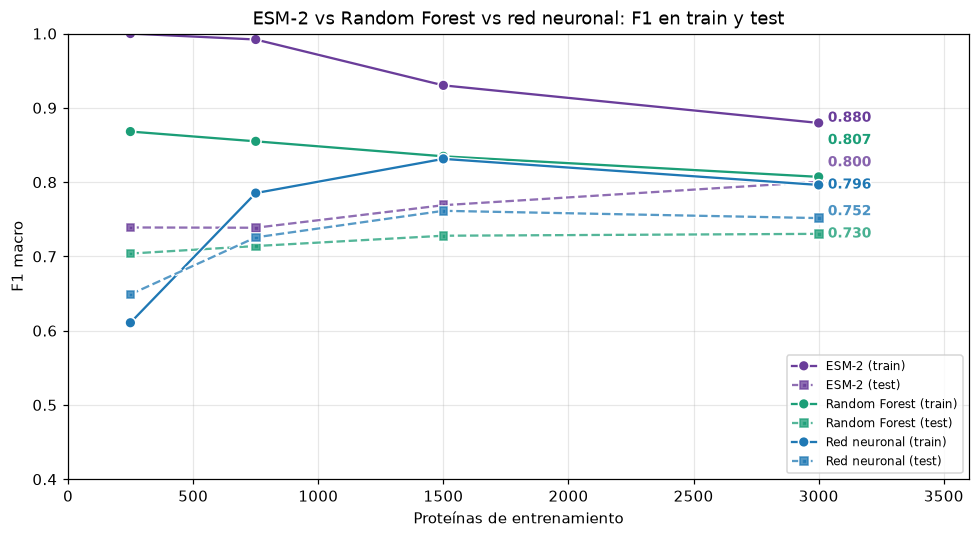

In [1]:
COLORES = {"ESM-2": "#6a3d9a", "Random Forest": "#1b9e77", "Red neuronal": "#1f78b4"}

fig, ax = plt.subplots(figsize=(9, 5))
extremos = []
for nombre, color in COLORES.items():
    d = resultados[resultados["modelo"] == nombre].sort_values("n_train")
    ax.plot(d["n_train"], d["F1_train"], "-", color=color, marker="o", markersize=5,
            label=f"{nombre} (train)",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    ax.plot(d["n_train"], d["F1_test"], "--", color=color, alpha=0.75, marker="s",
            markersize=5, label=f"{nombre} (test)",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    extremos.append([d["n_train"].iloc[-1], d["F1_train"].iloc[-1],
                     d["F1_train"].iloc[-1], color, 1.0])
    extremos.append([d["n_train"].iloc[-1], d["F1_test"].iloc[-1],
                     d["F1_test"].iloc[-1], color, 0.75])
extremos.sort(key=lambda e: e[2])
for i in range(1, len(extremos)):
    if extremos[i][2] - extremos[i - 1][2] < 0.03:
        extremos[i][2] = extremos[i - 1][2] + 0.03
for x, valor, yv, color, alpha in extremos:
    ax.annotate(f"{valor:.3f}", xy=(x, yv), xytext=(6, 0), textcoords="offset points",
                color=color, alpha=alpha, fontsize=9, fontweight="bold", va="center",
                ha="left", path_effects=[pe.withStroke(linewidth=2, foreground="white")])
ax.set_xlabel("Proteínas de entrenamiento")
ax.set_ylabel("F1 macro")
ax.set_ylim(0.4, 1.0)
ax.set_xlim(0, 3600)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("ESM-2 vs Random Forest vs red neuronal: F1 en train y test")
plt.tight_layout()
plt.show()

## Para pensar

1. ¿ESM-2 supera a Random Forest y a la red neuronal? ¿En test, cuánto?
2. ¿Cuál de los tres modelos tiene la brecha train–test más chica? ¿Qué te dice eso sobre cada representación?
3. ESM-2 nunca vio este dataset: ¿por qué igual le sirve? ¿Qué información trae el embedding que no capturan las features hechas a mano?
4. ¿Qué **costo** tiene ESM-2 comparado con contar aminoácidos (tiempo de cómputo, tamaño del modelo, dependencia de descargarlo)?